# Loan Approval Prediction with Deep Learning

This project predicts whether a loan application will be approved or not approved using machine learning models and a PyTorch neural network. The models are evaluated using Accuracy, Precision, Recall, F1-score, and ROC-AUC.

## Setup and Imports

In [1]:
import warnings
import copy

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from torch.utils.data import DataLoader, TensorDataset
from xgboost import XGBClassifier


warnings.filterwarnings("ignore")

RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

## 1. Data Loading

In [2]:
DATA_PATH = "../data/loan_risk_prediction_dataset.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (5000, 10)


,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved
0,56,48353.0,31258.0,675.0,20,Female,High School,Houston,Unemployed,0
1,69,57462.0,23262.0,586.0,6,Male,High School,San Francisco,Self-Employed,0
2,46,44219.0,26530.0,781.0,26,Male,PhD,Houston,Self-Employed,1
3,32,56307.0,11531.0,549.0,11,Male,NaN,New York,Unemployed,0
4,60,37034.0,27871.0,500.0,19,Female,High School,Chicago,Unemployed,0


## 2. Dataset Overview and Target Analysis

In [3]:
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nTarget distribution (counts):")
print(df["LoanApproved"].value_counts())

print("\nTarget distribution (proportions):")
print(df["LoanApproved"].value_counts(normalize=True))

Columns:
['Age', 'Income', 'LoanAmount', 'CreditScore', 'YearsExperience', 'Gender', 'Education', 'City', 'EmploymentType', 'LoanApproved']

Data types:
Age                  int64
Income             float64
LoanAmount         float64
CreditScore        float64
YearsExperience      int64
Gender                 str
Education              str
City                   str
EmploymentType         str
LoanApproved         int64
dtype: object

Missing values:
Age                  0
Income             196
LoanAmount           0
CreditScore        194
YearsExperience      0
Gender               0
Education          198
City                 0
EmploymentType       0
LoanApproved         0
dtype: int64

Target distribution (counts):
LoanApproved
0    3849
1    1151
Name: count, dtype: int64

Target distribution (proportions):
LoanApproved
0    0.7698
1    0.2302
Name: proportion, dtype: float64


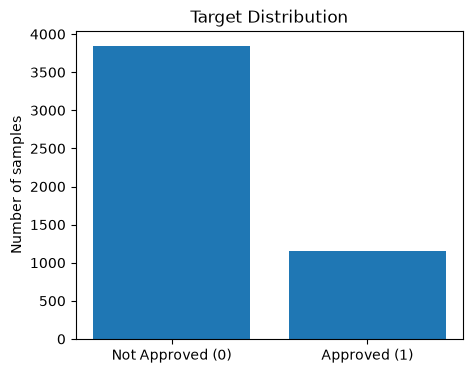

In [4]:
target_counts = df["LoanApproved"].value_counts().sort_index()

plt.figure(figsize=(5, 4))
plt.bar(["Not Approved (0)", "Approved (1)"], target_counts.values)
plt.title("Target Distribution")
plt.ylabel("Number of samples")
plt.show()

## 3. Feature and Target Definition

In [5]:
target_column = "LoanApproved"

X = df.drop(columns=[target_column])
y = df[target_column].astype(int)

print("Feature columns:")
print(X.columns.tolist())

print("\nTarget column:")
print(target_column)

Feature columns:
['Age', 'Income', 'LoanAmount', 'CreditScore', 'YearsExperience', 'Gender', 'Education', 'City', 'EmploymentType']

Target column:
LoanApproved


In [6]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Age', 'Income', 'LoanAmount', 'CreditScore', 'YearsExperience']

Categorical features:
['Gender', 'Education', 'City', 'EmploymentType']


## 4. Data Splitting and Preprocessing

In [7]:
# Split data into training and test sets
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=RANDOM_STATE,
    stratify=y
)

# Split the remaining data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.1765,
    random_state=RANDOM_STATE,
    stratify=y_train_full
)

print("Train size:", X_train.shape[0])
print("Validation size:", X_val.shape[0])
print("Test size:", X_test.shape[0])

print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True))

print("\nValidation target distribution:")
print(y_val.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))

Train size: 3499
Validation size: 751
Test size: 750

Train target distribution:
LoanApproved
0    0.769934
1    0.230066
Name: proportion, dtype: float64

Validation target distribution:
LoanApproved
0    0.76964
1    0.23036
Name: proportion, dtype: float64

Test target distribution:
LoanApproved
0    0.769333
1    0.230667
Name: proportion, dtype: float64


In [8]:
# Define preprocessing pipelines for numerical and categorical features
try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", onehot)
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

## 5. Classical Machine Learning Models

In [9]:
# Define a function to evaluate model performance
def evaluate_model(name, model, X_data, y_data):
    y_pred = model.predict(X_data)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_data)[:, 1]
    else:
        y_proba = y_pred

    results = {
        "Model": name,
        "Accuracy": accuracy_score(y_data, y_pred),
        "Precision": precision_score(y_data, y_pred, zero_division=0),
        "Recall": recall_score(y_data, y_pred, zero_division=0),
        "F1": f1_score(y_data, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_data, y_proba)
    }

    return results

In [10]:
# Calculate class imbalance for XGBoost
num_positive = y_train.sum()
num_negative = len(y_train) - num_positive

scale_pos_weight = num_negative / num_positive

print("Negative samples:", num_negative)
print("Positive samples:", num_positive)
print("scale_pos_weight for XGBoost:", scale_pos_weight)

Negative samples: 2694
Positive samples: 805
scale_pos_weight for XGBoost: 3.346583850931677


In [11]:
# Define machine learning models
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        min_samples_leaf=3,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE
    )
}

# Train models and evaluate them on the validation set
trained_models = {}
validation_results = []

for name, clf in models.items():
    print("Training:", name)

    pipeline = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", clf)
    ])

    pipeline.fit(X_train, y_train)

    trained_models[name] = pipeline

    result = evaluate_model(name, pipeline, X_val, y_val)
    validation_results.append(result)

validation_results_df = pd.DataFrame(validation_results)
validation_results_df.sort_values(by="F1", ascending=False)

Training: Logistic Regression
Training: Random Forest
Training: XGBoost


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
1,Random Forest,0.964048,0.962025,0.878613,0.918429,0.937626
2,XGBoost,0.962716,0.955975,0.878613,0.915663,0.942277
0,Logistic Regression,0.868176,0.662281,0.872832,0.753117,0.899064


## 6. Deep Learning Model with PyTorch

In [12]:
# Preprocess data and convert it to PyTorch tensors
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed validation shape:", X_val_processed.shape)
print("Processed test shape:", X_test_processed.shape)

Processed training shape: (3499, 18)
Processed validation shape: (751, 18)
Processed test shape: (750, 18)


In [13]:
X_train_tensor = torch.tensor(X_train_processed, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

X_val_tensor = torch.tensor(X_val_processed, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_processed, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

In [14]:
# Define the neural network architecture
class LoanApprovalMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.30),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.20),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)


input_dim = X_train_processed.shape[1]

deep_model = LoanApprovalMLP(input_dim)

print(deep_model)

LoanApprovalMLP(
  (network): Sequential(
    (0): Linear(in_features=18, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [15]:
# Define the loss function and optimizer
num_positive = y_train.sum()
num_negative = len(y_train) - num_positive

pos_weight_value = num_negative / num_positive
pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.Adam(
    deep_model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

print("Positive class weight:", pos_weight_value)

Positive class weight: 3.346583850931677


In [16]:
# Define a function to evaluate the neural network
def evaluate_pytorch_model(model, X_tensor, y_tensor, threshold=0.5):
    model.eval()

    with torch.no_grad():
        logits = model(X_tensor)
        probabilities = torch.sigmoid(logits).numpy().ravel()

    y_true = y_tensor.numpy().ravel()
    y_pred = (probabilities >= threshold).astype(int)

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, probabilities)
    }

# Train the neural network with early stopping
# Maximum number of epochs
num_epochs = 100

# Early stopping settings
patience = 10
min_delta = 0.0001

train_losses = []
val_f1_scores = []
val_auc_scores = []

best_val_auc = -np.inf
best_model_state = None
best_epoch = 0
epochs_without_improvement = 0

for epoch in range(num_epochs):
    deep_model.train()
    epoch_loss = 0

    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()

        logits = deep_model(batch_X)
        loss = criterion(logits, batch_y)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)

    val_metrics = evaluate_pytorch_model(
        deep_model,
        X_val_tensor,
        y_val_tensor,
        threshold=0.5
    )

    train_losses.append(avg_loss)
    val_f1_scores.append(val_metrics["F1"])
    val_auc_scores.append(val_metrics["ROC-AUC"])

    current_val_auc = val_metrics["ROC-AUC"]

    # Save the best model based on validation ROC-AUC
    if current_val_auc > best_val_auc + min_delta:
        best_val_auc = current_val_auc
        best_model_state = copy.deepcopy(deep_model.state_dict())
        best_epoch = epoch + 1
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(
            f"Epoch {epoch+1}/{num_epochs} | "
            f"Loss: {avg_loss:.4f} | "
            f"Val F1: {val_metrics['F1']:.4f} | "
            f"Val ROC-AUC: {val_metrics['ROC-AUC']:.4f}"
        )

    # Stop training if validation ROC-AUC does not improve
    if epochs_without_improvement >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

# Load the best model found during training
deep_model.load_state_dict(best_model_state)

print(f"Best epoch: {best_epoch}")
print(f"Best validation ROC-AUC: {best_val_auc:.4f}")

Epoch 1/100 | Loss: 0.9755 | Val F1: 0.6809 | Val ROC-AUC: 0.8897
Epoch 5/100 | Loss: 0.5035 | Val F1: 0.7712 | Val ROC-AUC: 0.9073
Epoch 10/100 | Loss: 0.4270 | Val F1: 0.7936 | Val ROC-AUC: 0.9166
Epoch 15/100 | Loss: 0.3938 | Val F1: 0.8310 | Val ROC-AUC: 0.9205
Epoch 20/100 | Loss: 0.3704 | Val F1: 0.8229 | Val ROC-AUC: 0.9211
Epoch 25/100 | Loss: 0.3614 | Val F1: 0.8646 | Val ROC-AUC: 0.9251
Epoch 30/100 | Loss: 0.3444 | Val F1: 0.8772 | Val ROC-AUC: 0.9279
Epoch 35/100 | Loss: 0.3334 | Val F1: 0.8728 | Val ROC-AUC: 0.9294
Epoch 40/100 | Loss: 0.3195 | Val F1: 0.8696 | Val ROC-AUC: 0.9316
Epoch 45/100 | Loss: 0.3121 | Val F1: 0.8817 | Val ROC-AUC: 0.9332
Epoch 50/100 | Loss: 0.3088 | Val F1: 0.8850 | Val ROC-AUC: 0.9349
Epoch 55/100 | Loss: 0.2984 | Val F1: 0.8830 | Val ROC-AUC: 0.9354
Epoch 60/100 | Loss: 0.2833 | Val F1: 0.8830 | Val ROC-AUC: 0.9347
Epoch 65/100 | Loss: 0.2751 | Val F1: 0.8862 | Val ROC-AUC: 0.9337
Epoch 70/100 | Loss: 0.2702 | Val F1: 0.8909 | Val ROC-AUC: 0.93

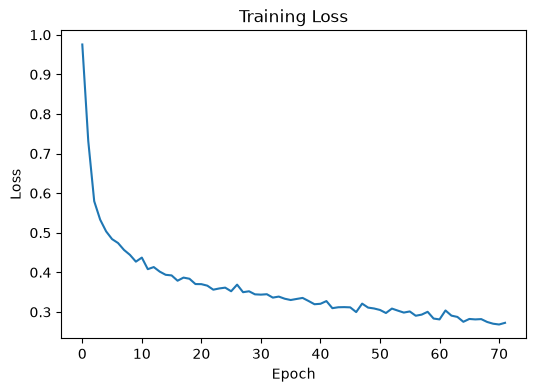

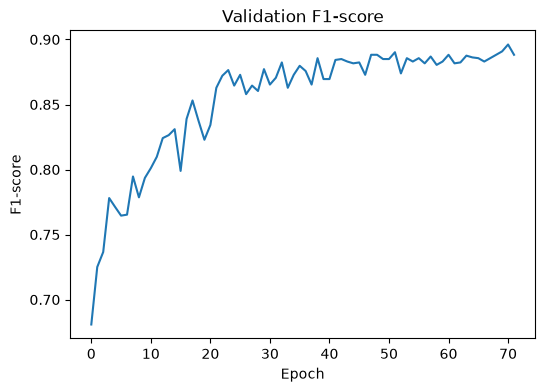

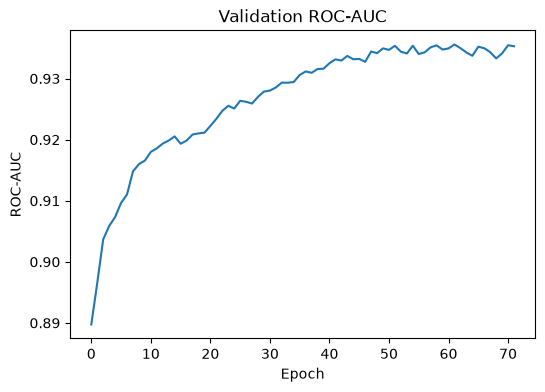

In [17]:
# Visualize training performance
plt.figure(figsize=(6, 4))
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(val_f1_scores)
plt.title("Validation F1-score")
plt.xlabel("Epoch")
plt.ylabel("F1-score")
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(val_auc_scores)
plt.title("Validation ROC-AUC")
plt.xlabel("Epoch")
plt.ylabel("ROC-AUC")
plt.show()

In [18]:
# Find the optimal classification threshold using the validation set
deep_model.eval()

with torch.no_grad():
    val_logits = deep_model(X_val_tensor)
    val_probabilities = torch.sigmoid(val_logits).numpy().ravel()

y_val_true = y_val_tensor.numpy().ravel()

thresholds = np.arange(0.05, 0.95, 0.01)

best_threshold = 0.5
best_f1 = 0

for threshold in thresholds:
    val_predictions = (val_probabilities >= threshold).astype(int)
    current_f1 = f1_score(y_val_true, val_predictions)

    if current_f1 > best_f1:
        best_f1 = current_f1
        best_threshold = threshold

print("Best threshold:", best_threshold)
print("Best validation F1:", best_f1)

Best threshold: 0.5800000000000002
Best validation F1: 0.8922155688622755


In [19]:
# Evaluate the neural network using the optimal threshold
nn_val_metrics = evaluate_pytorch_model(
    deep_model,
    X_val_tensor,
    y_val_tensor,
    threshold=best_threshold
)

nn_val_metrics["Model"] = "Neural Network"

nn_val_metrics

{'Accuracy': 0.952063914780293,
 'Precision': 0.9254658385093167,
 'Recall': 0.861271676300578,
 'F1': 0.8922155688622755,
 'ROC-AUC': 0.9355761345680741,
 'Model': 'Neural Network'}

## 7. Model Comparison and Selection

In [20]:
# Combine validation results and compare all models
all_validation_results = validation_results_df.copy()

nn_val_row = pd.DataFrame([{
    "Model": "Neural Network",
    "Accuracy": nn_val_metrics["Accuracy"],
    "Precision": nn_val_metrics["Precision"],
    "Recall": nn_val_metrics["Recall"],
    "F1": nn_val_metrics["F1"],
    "ROC-AUC": nn_val_metrics["ROC-AUC"]
}])

all_validation_results = pd.concat(
    [all_validation_results, nn_val_row],
    ignore_index=True
)

all_validation_results = all_validation_results.sort_values(
    by="F1",
    ascending=False
).reset_index(drop=True)

all_validation_results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Random Forest,0.964048,0.962025,0.878613,0.918429,0.937626
1,XGBoost,0.962716,0.955975,0.878613,0.915663,0.942277
2,Neural Network,0.952064,0.925466,0.861272,0.892216,0.935576
3,Logistic Regression,0.868176,0.662281,0.872832,0.753117,0.899064


In [21]:
best_model_name = all_validation_results.iloc[0]["Model"]

print("Best model based on validation F1-score:", best_model_name)

Best model based on validation F1-score: Random Forest


## 8. Final Test Set Evaluation

In [22]:
# Evaluate all models on the final test set
test_results = []

for name, model in trained_models.items():
    result = evaluate_model(name, model, X_test, y_test)
    test_results.append(result)

nn_test_metrics = evaluate_pytorch_model(
    deep_model,
    X_test_tensor,
    y_test_tensor,
    threshold=best_threshold
)

nn_test_row = {
    "Model": "Neural Network",
    "Accuracy": nn_test_metrics["Accuracy"],
    "Precision": nn_test_metrics["Precision"],
    "Recall": nn_test_metrics["Recall"],
    "F1": nn_test_metrics["F1"],
    "ROC-AUC": nn_test_metrics["ROC-AUC"]
}

test_results.append(nn_test_row)

test_results_df = pd.DataFrame(test_results)

test_results_df.sort_values(by="F1", ascending=False)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
1,Random Forest,0.962667,0.944785,0.890173,0.916667,0.933992
2,XGBoost,0.960000,0.938650,0.884393,0.910714,0.928206
3,Neural Network,0.946667,0.888889,0.878613,0.883721,0.923303
0,Logistic Regression,0.842667,0.607843,0.895954,0.724299,0.907805


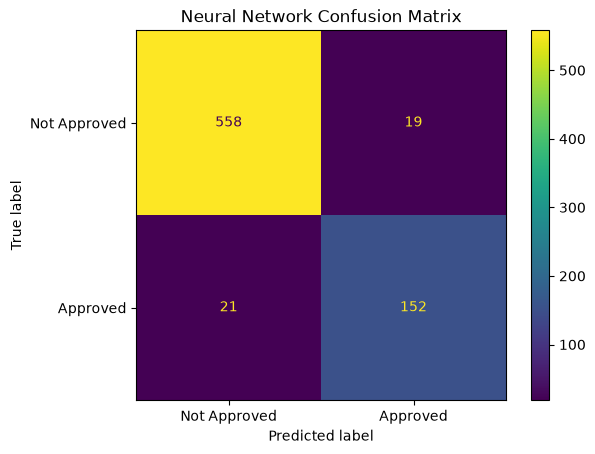

              precision    recall  f1-score   support

Not Approved       0.96      0.97      0.97       577
    Approved       0.89      0.88      0.88       173

    accuracy                           0.95       750
   macro avg       0.93      0.92      0.92       750
weighted avg       0.95      0.95      0.95       750



In [23]:
# Visualize the Neural Network test performance
deep_model.eval()

with torch.no_grad():
    test_logits = deep_model(X_test_tensor)
    test_probabilities = torch.sigmoid(test_logits).numpy().ravel()

test_predictions = (test_probabilities >= best_threshold).astype(int)
y_test_true = y_test_tensor.numpy().ravel()

cm = confusion_matrix(y_test_true, test_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Approved", "Approved"]
)

disp.plot()
plt.title("Neural Network Confusion Matrix")
plt.show()

print(classification_report(
    y_test_true,
    test_predictions,
    target_names=["Not Approved", "Approved"]
))

## 9. Feature Importance Analysis

In [24]:
# Extract feature names after preprocessing
def get_feature_names_from_pipeline(pipeline):
    onehot_encoder = pipeline.named_steps["preprocess"].named_transformers_["cat"].named_steps["onehot"]

    feature_names_num = numeric_features
    feature_names_cat = onehot_encoder.get_feature_names_out(categorical_features).tolist()

    return feature_names_num + feature_names_cat


# Random Forest feature importance
rf_model = trained_models["Random Forest"]
rf_feature_names = get_feature_names_from_pipeline(rf_model)

rf_importance_df = pd.DataFrame({
    "Feature": rf_feature_names,
    "Importance": rf_model.named_steps["model"].feature_importances_
}).sort_values(by="Importance", ascending=False)


# XGBoost feature importance
xgb_model = trained_models["XGBoost"]
xgb_feature_names = get_feature_names_from_pipeline(xgb_model)

xgb_importance_df = pd.DataFrame({
    "Feature": xgb_feature_names,
    "Importance": xgb_model.named_steps["model"].feature_importances_
}).sort_values(by="Importance", ascending=False)


print("Top Random Forest features:")
display(rf_importance_df.head(10))

print("Top XGBoost features:")
display(xgb_importance_df.head(10))

Top Random Forest features:


,Feature,Importance
3,CreditScore,0.489044
1,Income,0.174745
17,EmploymentType_Unemployed,0.166447
16,EmploymentType_Self-Employed,0.033014
2,LoanAmount,0.031556
15,EmploymentType_Salaried,0.029018
0,Age,0.025521
4,YearsExperience,0.023857
13,City_New York,0.003431
10,Education_PhD,0.002950


Top XGBoost features:


,Feature,Importance
17,EmploymentType_Unemployed,0.332485
3,CreditScore,0.176678
15,EmploymentType_Salaried,0.135413
1,Income,0.081218
16,EmploymentType_Self-Employed,0.047034
6,Gender_Male,0.027753
2,LoanAmount,0.020281
13,City_New York,0.019746
12,City_Houston,0.019075
0,Age,0.018448


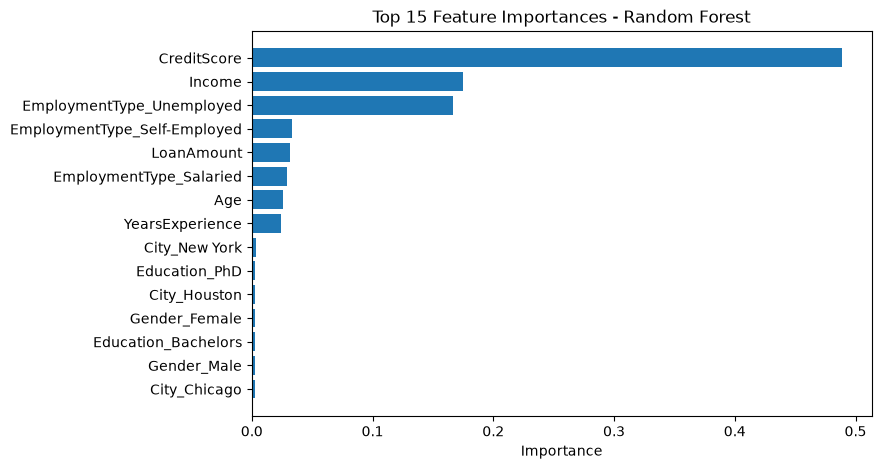

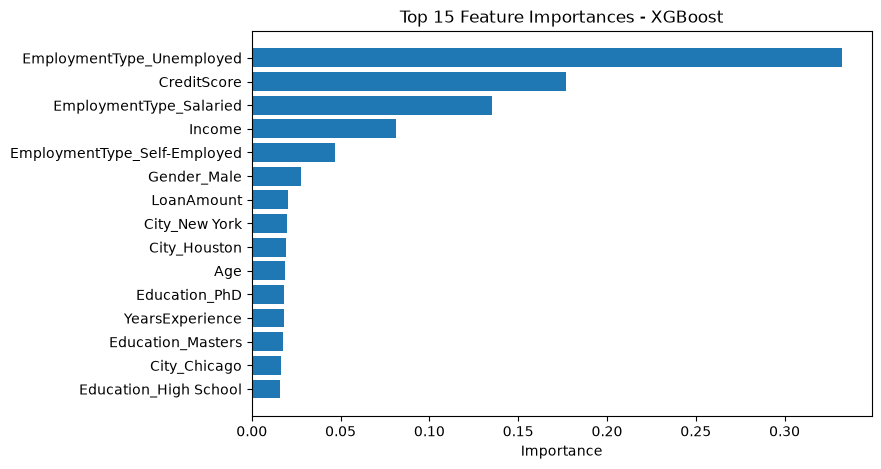

In [25]:
top_rf = rf_importance_df.head(15)

plt.figure(figsize=(8, 5))
plt.barh(top_rf["Feature"][::-1], top_rf["Importance"][::-1])
plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.show()


top_xgb = xgb_importance_df.head(15)

plt.figure(figsize=(8, 5))
plt.barh(top_xgb["Feature"][::-1], top_xgb["Importance"][::-1])
plt.title("Top 15 Feature Importances - XGBoost")
plt.xlabel("Importance")
plt.show()

## 10. Example Predictions

In [26]:
# Create a hypothetical loan applicant to demonstrate model predictions
example_applicant = pd.DataFrame([{
    "Age": 35,
    "Income": 60000,
    "LoanAmount": 15000,
    "CreditScore": 720,
    "YearsExperience": 8,
    "Gender": "Female",
    "Education": "Bachelor",
    "City": "New York",
    "EmploymentType": "Employed"
}])

print(example_applicant)

   Age  Income  LoanAmount  CreditScore  YearsExperience  Gender Education  \
0   35   60000       15000          720                8  Female  Bachelor   

       City EmploymentType  
0  New York       Employed  


In [27]:
# Random Forest prediction
rf_probability = trained_models["Random Forest"].predict_proba(example_applicant)[0, 1]
rf_prediction = trained_models["Random Forest"].predict(example_applicant)[0]

print("Random Forest probability of approval:", rf_probability)
print("Random Forest prediction:", rf_prediction)


# XGBoost prediction
xgb_probability = trained_models["XGBoost"].predict_proba(example_applicant)[0, 1]
xgb_prediction = trained_models["XGBoost"].predict(example_applicant)[0]

print("XGBoost probability of approval:", xgb_probability)
print("XGBoost prediction:", xgb_prediction)


# Neural Network prediction
example_processed = preprocessor.transform(example_applicant)
example_tensor = torch.tensor(example_processed, dtype=torch.float32)

deep_model.eval()

with torch.no_grad():
    logit = deep_model(example_tensor)
    probability = torch.sigmoid(logit).item()

nn_prediction = int(probability >= best_threshold)

print("Neural Network probability of approval:", probability)
print("Neural Network prediction:", nn_prediction)

Random Forest probability of approval: 0.8051327243018419
Random Forest prediction: 1
XGBoost probability of approval: 0.9758066
XGBoost prediction: 1
Neural Network probability of approval: 0.9769256114959717
Neural Network prediction: 1


## 11. Saving Models and Results

In [28]:
# Save trained models, preprocessing objects, and project results
import json
import os

# Create output folders if they do not exist
os.makedirs("../models", exist_ok=True)
os.makedirs("../outputs", exist_ok=True)

# Save result tables
test_results_df.to_csv("../outputs/test_results.csv", index=False)

# Save feature importance files
rf_importance_df.to_csv(
    "../outputs/random_forest_feature_importance.csv",
    index=False
)

xgb_importance_df.to_csv(
    "../outputs/xgboost_feature_importance.csv",
    index=False
)

# Save trained classical ML models
joblib.dump(
    trained_models["Random Forest"],
    "../models/random_forest_model.pkl"
)

joblib.dump(
    trained_models["XGBoost"],
    "../models/xgboost_model.pkl"
)

joblib.dump(
    trained_models["Logistic Regression"],
    "../models/logistic_regression_model.pkl"
)

# Save preprocessor for neural network
joblib.dump(
    preprocessor,
    "../models/neural_network_preprocessor.pkl"
)

# Save neural network model + useful information
torch.save({
    "model_state_dict": deep_model.state_dict(),
    "input_dim": input_dim,
    "best_threshold": float(best_threshold)
}, "../models/neural_network_checkpoint.pth")

# Save neural network config as readable JSON
nn_config = {
    "input_dim": int(input_dim),
    "best_threshold": float(best_threshold)
}

with open("../models/neural_network_config.json", "w") as f:
    json.dump(nn_config, f, indent=4)

print("Models and outputs saved successfully.")

Models and outputs saved successfully.


## 12. Model Explainability with SHAP

In [29]:
import shap
import os

os.makedirs("../outputs/shap", exist_ok=True)

In [30]:
# Use the best model: Random Forest
rf_pipeline = trained_models["Random Forest"]

# Separate preprocessing and model parts
rf_preprocessor = rf_pipeline.named_steps["preprocess"]
rf_classifier = rf_pipeline.named_steps["model"]

# Get final feature names after one-hot encoding
onehot_encoder = rf_preprocessor.named_transformers_["cat"].named_steps["onehot"]

feature_names_num = numeric_features
feature_names_cat = onehot_encoder.get_feature_names_out(categorical_features).tolist()

shap_feature_names = feature_names_num + feature_names_cat

# Transform train and test data using the fitted preprocessor
X_train_rf_processed = rf_preprocessor.transform(X_train)
X_test_rf_processed = rf_preprocessor.transform(X_test)

# Convert to DataFrame for better SHAP plots
X_train_rf_df = pd.DataFrame(X_train_rf_processed, columns=shap_feature_names)
X_test_rf_df = pd.DataFrame(X_test_rf_processed, columns=shap_feature_names)

print("SHAP input shape:", X_test_rf_df.shape)

SHAP input shape: (750, 18)


In [31]:
# Use a small background sample to make SHAP faster
background_size = min(500, len(X_train_rf_df))

X_background = X_train_rf_df.sample(
    n=background_size,
    random_state=RANDOM_STATE
)

# Create TreeExplainer for Random Forest
rf_explainer = shap.TreeExplainer(rf_classifier, X_background)

# Compute SHAP values for the test set
raw_shap_values = rf_explainer.shap_values(X_test_rf_df)

print("SHAP values computed.")

Background dataset has 500 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=500 when initializing the masker.
 97%|=================== | 1460/1500 [00:33<00:00]       

SHAP values computed.


In [32]:
def get_class1_shap_values(raw_values, explainer):
    """
    Extract SHAP values for class 1 = Approved.
    This handles different SHAP versions.
    """
    # Old SHAP style: list with one array per class
    if isinstance(raw_values, list):
        shap_class1 = raw_values[1]
        base_value_class1 = explainer.expected_value[1]

    # Newer SHAP style: 3D array: samples x features x classes
    elif len(np.array(raw_values).shape) == 3:
        shap_class1 = raw_values[:, :, 1]
        base_value_class1 = explainer.expected_value[1]

    # Binary output style
    else:
        shap_class1 = raw_values
        base_value_class1 = explainer.expected_value

    return shap_class1, base_value_class1


shap_values_class1, shap_base_value_class1 = get_class1_shap_values(
    raw_shap_values,
    rf_explainer
)

print("Class 1 SHAP shape:", shap_values_class1.shape)
print("Base value for Approved class:", shap_base_value_class1)

Class 1 SHAP shape: (750, 18)
Base value for Approved class: 0.28646674549117557


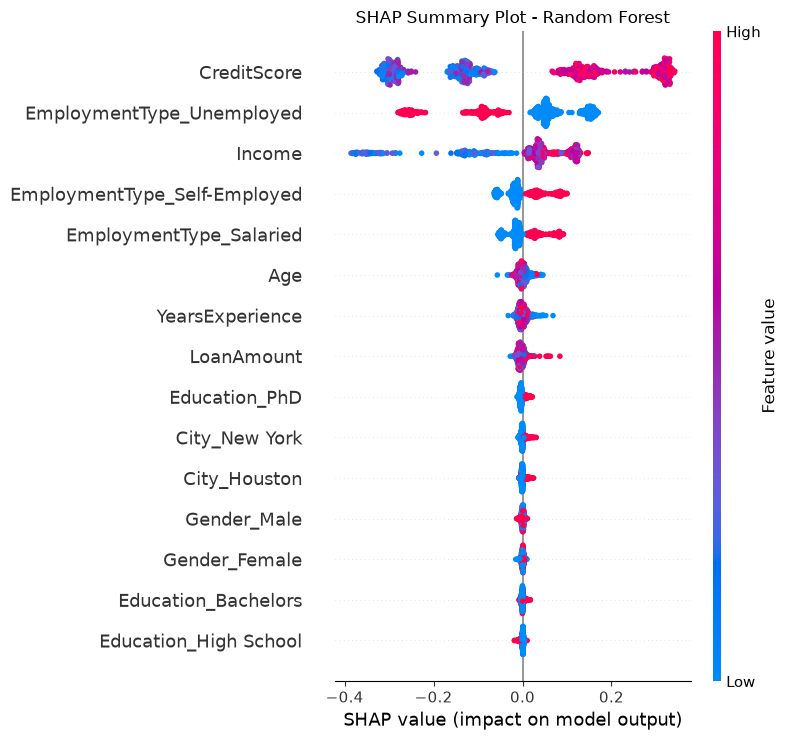

In [33]:
plt.figure()
shap.summary_plot(
    shap_values_class1,
    X_test_rf_df,
    max_display=15,
    show=False
)

plt.title("SHAP Summary Plot - Random Forest")
plt.tight_layout()
plt.savefig(
    "../outputs/shap/shap_summary_random_forest.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [34]:
def explain_applicant(index_in_test):
    """
    Explain why Random Forest approved or rejected one applicant from the test set.
    """

    # Original applicant row before preprocessing
    applicant_original = X_test.iloc[[index_in_test]]

    # Model prediction
    probability_approved = rf_pipeline.predict_proba(applicant_original)[0, 1]
    prediction = rf_pipeline.predict(applicant_original)[0]
    true_label = y_test.iloc[index_in_test]

    decision = "Approved" if prediction == 1 else "Not Approved"

    print("Applicant index in test set:", index_in_test)
    print("Model prediction:", decision)
    print("Probability of approval:", round(probability_approved, 4))
    print("True label:", true_label)

    print("\nOriginal applicant data:")
    display(applicant_original)

    # SHAP values for this applicant
    applicant_shap_values = shap_values_class1[index_in_test]
    applicant_processed_values = X_test_rf_df.iloc[index_in_test].values

    local_explanation = pd.DataFrame({
        "Feature": shap_feature_names,
        "Processed Value": applicant_processed_values,
        "SHAP Contribution Toward Approval": applicant_shap_values
    })

    local_explanation["Absolute Contribution"] = local_explanation[
        "SHAP Contribution Toward Approval"
    ].abs()

    local_explanation = local_explanation.sort_values(
        by="Absolute Contribution",
        ascending=False
    )

    print("\nTop features explaining this decision:")
    display(local_explanation.head(10))

    # Waterfall plot
    explanation_object = shap.Explanation(
        values=applicant_shap_values,
        base_values=shap_base_value_class1,
        data=applicant_processed_values,
        feature_names=shap_feature_names
    )

    shap.plots.waterfall(explanation_object, max_display=12)

In [35]:
rf_test_probabilities = rf_pipeline.predict_proba(X_test)[:, 1]
rf_test_predictions = rf_pipeline.predict(X_test)

# Most confidently approved applicant
accepted_example_index = int(np.argmax(rf_test_probabilities))

# Most confidently rejected applicant
rejected_example_index = int(np.argmin(rf_test_probabilities))

print("Most confidently approved index:", accepted_example_index)
print("Most confidently rejected index:", rejected_example_index)

Most confidently approved index: 391
Most confidently rejected index: 80


Applicant index in test set: 391
Model prediction: Approved
Probability of approval: 0.9876
True label: 1

Original applicant data:


,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType
2316,39,61525.0,21847.0,683.0,14,Female,Bachelors,San Francisco,Salaried



Top features explaining this decision:


,Feature,Processed Value,SHAP Contribution Toward Approval,Absolute Contribution
3,CreditScore,0.684035,0.338089,0.338089
17,EmploymentType_Unemployed,0.000000,0.170913,0.170913
1,Income,0.803438,0.106265,0.106265
15,EmploymentType_Salaried,1.000000,0.083702,0.083702
16,EmploymentType_Self-Employed,0.000000,-0.017572,0.017572
4,YearsExperience,-0.497473,0.005947,0.005947
0,Age,-0.313467,0.005339,0.005339
2,LoanAmount,0.242630,0.003265,0.003265
10,Education_PhD,0.000000,-0.002141,0.002141
5,Gender_Female,1.000000,0.002107,0.002107


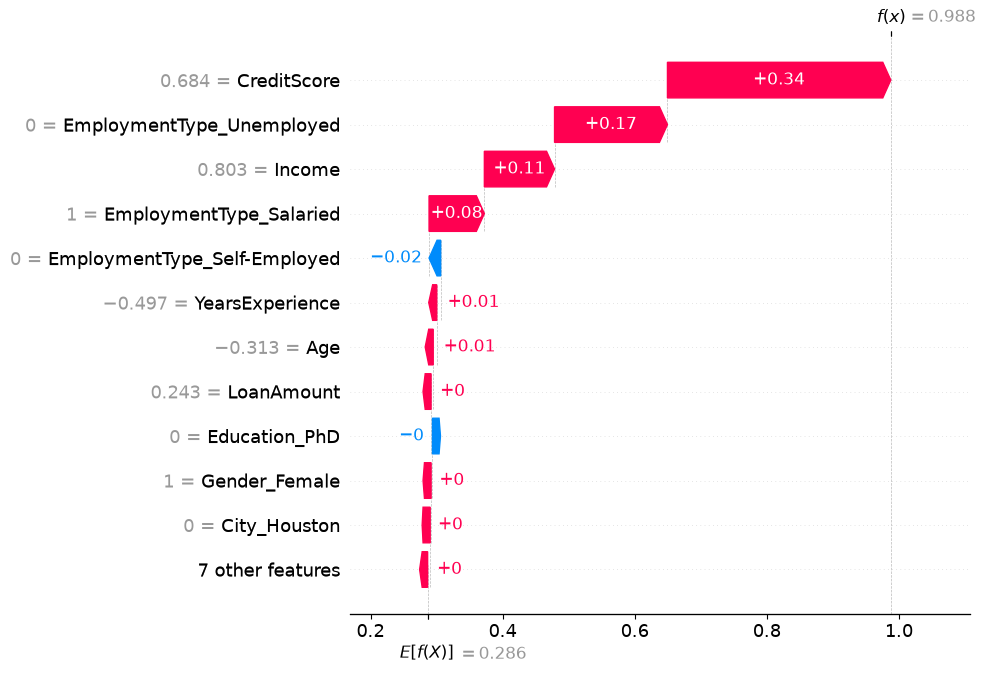

In [36]:
explain_applicant(accepted_example_index)

Applicant index in test set: 80
Model prediction: Not Approved
Probability of approval: 0.0065
True label: 0

Original applicant data:


,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType
1418,49,NaN,27752.0,NaN,12,Female,Bachelors,Chicago,Unemployed



Top features explaining this decision:


,Feature,Processed Value,SHAP Contribution Toward Approval,Absolute Contribution
3,CreditScore,0.015685,-0.122781,0.122781
17,EmploymentType_Unemployed,1.000000,-0.091909,0.091909
16,EmploymentType_Self-Employed,0.000000,-0.022857,0.022857
15,EmploymentType_Salaried,0.000000,-0.017879,0.017879
1,Income,-0.017319,0.015266,0.015266
4,YearsExperience,-0.670811,-0.010381,0.010381
2,LoanAmount,0.973794,-0.008763,0.008763
0,Age,0.351192,-0.007760,0.007760
10,Education_PhD,0.000000,-0.003609,0.003609
9,Education_Masters,0.000000,-0.002552,0.002552


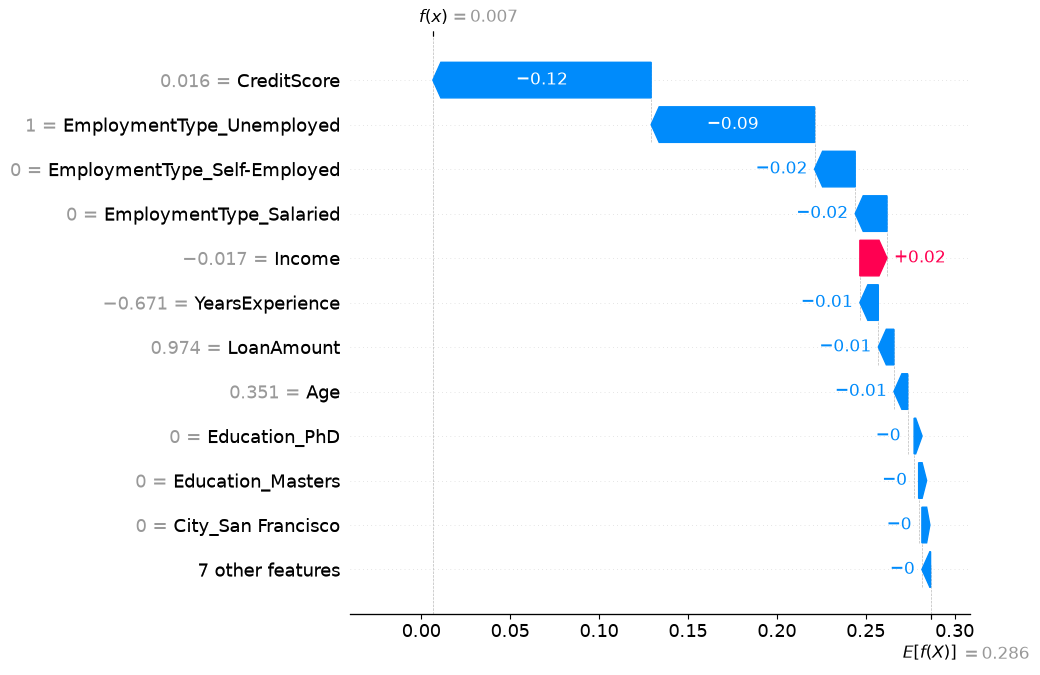

In [37]:
explain_applicant(rejected_example_index)

In [38]:
def save_applicant_shap_table(index_in_test, filename):
    applicant_shap_values = shap_values_class1[index_in_test]
    applicant_processed_values = X_test_rf_df.iloc[index_in_test].values

    local_explanation = pd.DataFrame({
        "Feature": shap_feature_names,
        "Processed Value": applicant_processed_values,
        "SHAP Contribution Toward Approval": applicant_shap_values
    })

    local_explanation["Absolute Contribution"] = local_explanation[
        "SHAP Contribution Toward Approval"
    ].abs()

    local_explanation = local_explanation.sort_values(
        by="Absolute Contribution",
        ascending=False
    )

    local_explanation.to_csv(
    f"../outputs/shap/{filename}",
    index=False
    )


save_applicant_shap_table(
    accepted_example_index,
    "shap_accepted_applicant_explanation.csv"
)

save_applicant_shap_table(
    rejected_example_index,
    "shap_rejected_applicant_explanation.csv"
)

print("Saved SHAP explanation tables.")

Saved SHAP explanation tables.
